--- 1. Problema sin restricciones ---
Solución: [0. 0.], Iteraciones: 2

--- 2. Problema con restricciones (x+y >= 2) ---
Solución: [0.84375 1.125  ], Iteraciones: 500

--- 3. Generando estudio de hiperparámetros... ---


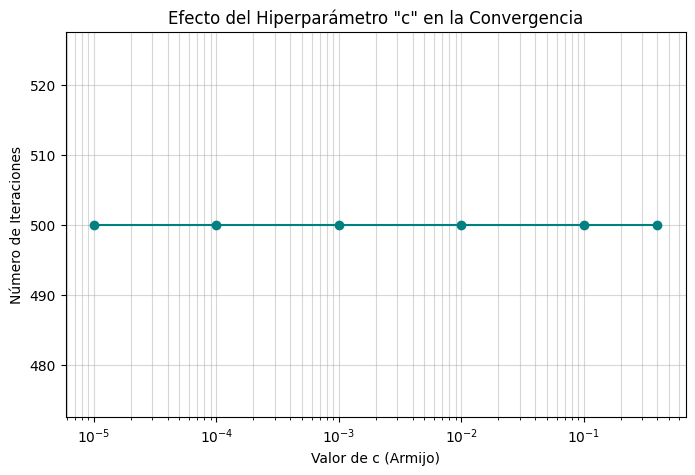

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. DEFINICIÓN DE PROBLEMAS (Funciones de Wikipedia)
# ---------------------------------------------------------

# Problema sin restricciones: Función Esfera f(x,y) = x^2 + y^2 [cite: 6]
def f_objetivo(x):
    return np.sum(x**2)

def grad_objetivo(x):
    return 2 * x

# Problema con restricciones: f(x,y) con restricción x + y >= 2 [cite: 8]
# Usamos el Método de Penalización 
def f_penalizada(x, mu):
    f_x = f_objetivo(x)
    # Restricción: g(x) = x + y - 2 >= 0
    g_x = x[0] + x[1] - 2
    penalizacion = mu * (max(0, -g_x))**2
    return f_x + penalizacion

def grad_penalizado(x, mu):
    g_x = x[0] + x[1] - 2
    grad_f = grad_objetivo(x)
    if g_x < 0:
        grad_p = mu * 2 * (x[0] + x[1] - 2) * np.array([-1.0, -1.0])
        return grad_f + grad_p
    return grad_f

# ---------------------------------------------------------
# 2. ALGORITMO: DESCENSO DE GRADIENTE CON ARMIJO [cite: 5, 20]
# ---------------------------------------------------------

def descenso_gradiente_armijo(x0, f, grad_f, tol=1e-5, max_iter=500, alpha=0.5, c=1e-4):
    x = np.array(x0, dtype=float)
    historial_puntos = [x.copy()]
    
    for i in range(max_iter):
        g = grad_f(x)
        norm_g = np.linalg.norm(g)
        
        if norm_g < tol:
            break
            
        # Búsqueda lineal de Armijo para el tamaño del paso (t)
        t = 1.0
        while f(x - t * g) > f(x) - c * t * (norm_g**2):
            t *= alpha
            if t < 1e-12: break # Evitar bucle infinito
            
        x = x - t * g
        historial_puntos.append(x.copy())
        
    return x, i + 1

# ---------------------------------------------------------
# 3. ESTUDIO DE COMPORTAMIENTO (Hiperparámetros) [cite: 9, 14]
# ---------------------------------------------------------

def realizar_estudio():
    # Variamos el hiperparámetro 'c' de Armijo (condición de descenso) 
    valores_c = [1e-5, 1e-4, 1e-3, 0.01, 0.1, 0.4]
    iteraciones = []
    
    x_inicio = [5.0, 5.0]
    mu_fijo = 100 # Parámetro de penalización
    
    for val in valores_c:
        _, n_iter = descenso_gradiente_armijo(
            x_inicio, 
            lambda x: f_penalizada(x, mu_fijo), 
            lambda x: grad_penalizado(x, mu_fijo),
            c=val
        )
        iteraciones.append(n_iter)
    
    # Graficar resultados para la memoria [cite: 14]
    plt.figure(figsize=(8, 5))
    plt.plot(valores_c, iteraciones, marker='o', color='teal')
    plt.xscale('log')
    plt.title('Efecto del Hiperparámetro "c" en la Convergencia')
    plt.xlabel('Valor de c (Armijo)')
    plt.ylabel('Número de Iteraciones')
    plt.grid(True, which="both", ls="-", alpha=0.5)
    plt.show()

# ---------------------------------------------------------
# EJECUCIÓN PRINCIPAL
# ---------------------------------------------------------

if __name__ == "__main__":
    x_ini = [3.0, 4.0]
    
    print("--- 1. Problema sin restricciones ---")
    sol1, iter1 = descenso_gradiente_armijo(x_ini, f_objetivo, grad_objetivo)
    print(f"Solución: {sol1}, Iteraciones: {iter1}")
    
    print("\n--- 2. Problema con restricciones (x+y >= 2) ---")
    sol2, iter2 = descenso_gradiente_armijo(x_ini, lambda x: f_penalizada(x, 100), 
                                            lambda x: grad_penalizado(x, 100))
    print(f"Solución: {sol2}, Iteraciones: {iter2}")
    
    print("\n--- 3. Generando estudio de hiperparámetros... ---")
    realizar_estudio()